In [31]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Read the input file 'Diabetes.csv' using Pandas and check it's column names(1 Marks)

In [2]:
df=pd.read_csv('diabetes.csv')

In [3]:
# Eye ball the imported dataset
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Check dimension of dataset

In [21]:
print("Diabetes data set dimensions : {}".format(df.shape))

Diabetes data set dimensions : (768, 9)


### Check distribution of dependent variable, Outcome and plot it (1 Marks)

In [18]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000019A21F5A6D8>,
      dtype=object)

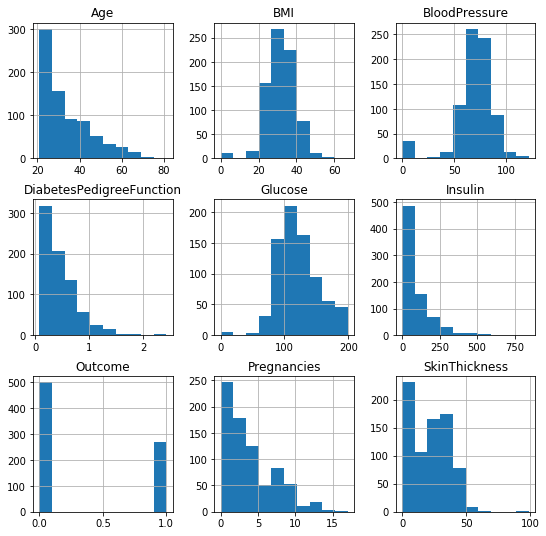

In [25]:
df.hist(figsize=(9, 9))


Outcome
0    [[AxesSubplot(0.125,0.670278;0.215278x0.209722...
1    [[AxesSubplot(0.125,0.670278;0.215278x0.209722...
dtype: object

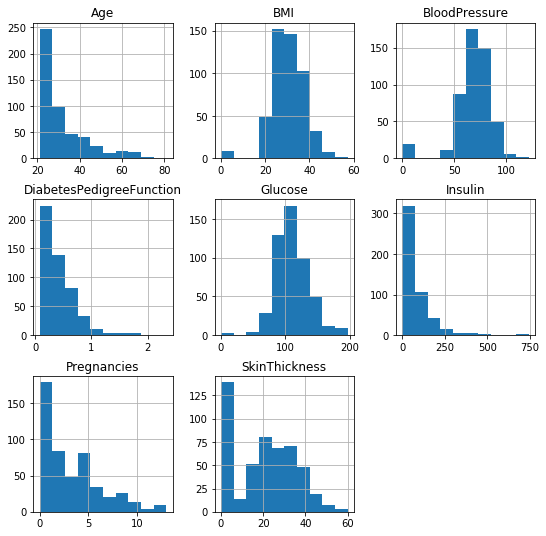

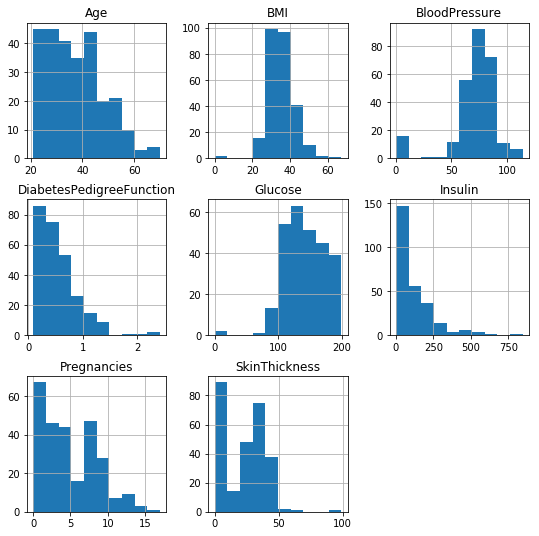

In [26]:
df.groupby('Outcome').hist(figsize=(9, 9))


In [8]:
# Check data types and info of dataset
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

### Check data distribution using summary statistics and provide your findings(2 Marks)

In [28]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Do correlation analysis and bivariate viualization with Insights(1 Marks)

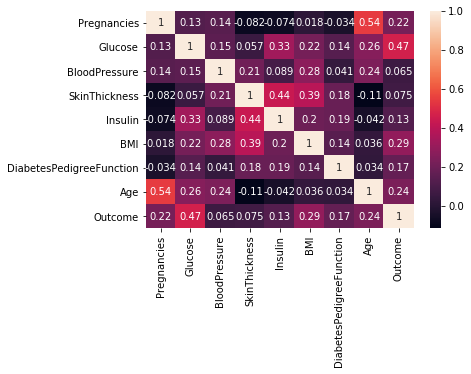

In [33]:
sns.heatmap(df.corr(), annot = True)

In [46]:
#We can see for Glucose, BloodPressure, SkinThickness, Insulin, 
#BMI the minimum is 0 for some fields we will replace them with the mean of the fields not equal to zero. 

fields = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for field in fields :
    print('field %s : num 0-entries: %d' % (field, len(df.loc[ df[field] == 0, field ])))

field Glucose : num 0-entries: 5
field BloodPressure : num 0-entries: 35
field SkinThickness : num 0-entries: 227
field Insulin : num 0-entries: 374
field BMI : num 0-entries: 11


In [43]:
data_arr = df.values
X = data_arr[:,0:8]
Y = data_arr[:,8]
print(data_arr.shape)
print(X.shape)
print(Y.shape)

(768, 9)
(768, 8)
(768,)


#### Do train and test split with stratify sampling on Outcome variable to maintain the distribution of dependent variable(1 Marks)

In [65]:
from sklearn.model_selection import train_test_split

test_size = 0.25
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size)

### Train Support Vector Machine Model(1 Marks)

In [ ]:
# use from sklearn.svm import SVC

In [68]:
from sklearn.svm import SVC # "Support vector classifier"

trainedsvm = svm.SVC().fit(X_train, Y_train)
predictionsvm = trainedsvm.predict(X_test)
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

C:\Users\selvm\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


NameError: name 'y' is not defined

### Scale the data points using MinMaxScaler ( 1 Marks)

In [64]:
from sklearn.preprocessing import MinMaxScaler
transforms = MinMaxScaler(feature_range=(0,1))
scaler_X =  transforms.fit_transform()
print(scaler_X)

TypeError: fit_transform() missing 1 required positional argument: 'X'

### Fit SVM Model on Scale data and give your observation( 1 Marks)

In [55]:
# Use the whole dataset to train the model
X = np.append(train_set_scaled, test_set_scaled, axis=0)
Y = np.append(train_set_labels, test_set_labels, axis=0)

# Train the model
svc.fit(X, Y)

NameError: name 'grid_search' is not defined

#we can try increasing either C or gamma to fit a more complex model.

### Try improving the model accuracy using C=1000 (1 Marks)

In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1.0, 10.0, 50.0],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'shrinking': [True, False],
    'gamma': ['auto', 1, 0.1],
    'coef0': [0.0, 0.1, 0.5]
}

model_svc = SVC()

grid_search = GridSearchCV(
    model_svc, param_grid, cv=10, scoring='accuracy')
grid_search.fit(train_set_scaled, train_set_labels)

NameError: name 'SVC' is not defined

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [19]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [20]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [21]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [22]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [23]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [24]:
gs.best_score_ 

0.77777777777777779